<a href="https://colab.research.google.com/github/jakubwidorski/gkipo/blob/main/Zadanie2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- START ANALIZY OBRAZU: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d1/Stormy_Dawn_on_Penang_Island_%2850035925527%29.jpg/960px-Stormy_Dawn_on_Penang_Island_%2850035925527%29.jpg ---
Pobieranie obrazu: https://upload.wikimedia.org/wikipedia/commons/thumb/d/d1/Stormy_Dawn_on_Penang_Island_%2850035925527%29.jpg/960px-Stormy_Dawn_on_Penang_Island_%2850035925527%29.jpg

--- METRYKI ---
Średnia jasność (Mean): 87.62 (optymalnie: 100-155)
Odchylenie std. (Std. Dev.): 58.83 (dobry kontrast > 45)
---------------

DIAGNOZA ORYGINAŁU: Ekspozycja OK


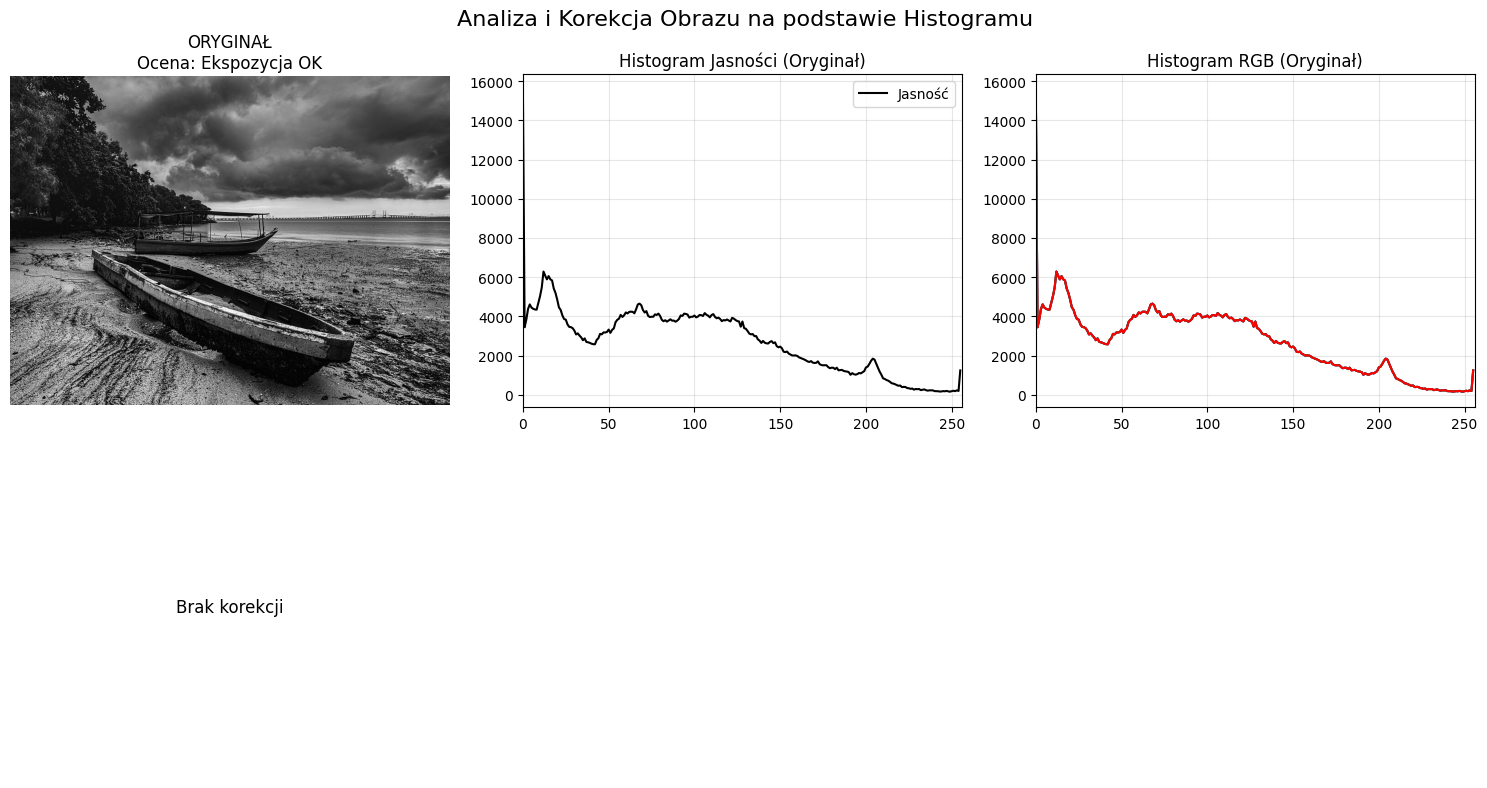

In [40]:
import requests
import numpy as np
import cv2
from matplotlib import pyplot as plt


URL_ZDJECIA = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d1/Stormy_Dawn_on_Penang_Island_%2850035925527%29.jpg/960px-Stormy_Dawn_on_Penang_Island_%2850035925527%29.jpg"

def pobierz_obraz_zdalny(url):
    """Pobiera obraz zdalny, używając wzmocnionych nagłówków, aby uniknąć błędu 403."""
    print(f"Pobieranie obrazu: {url}")


    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'Accept': 'image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8',
        'Accept-Encoding': 'gzip, deflate, br',
        'Connection': 'keep-alive'
    }

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        image_array = np.asarray(bytearray(response.content), dtype="uint8")
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

        if image is None:
            raise ValueError("Pobrano dane, ale nie udało się zdekodować obrazu. Sprawdź format pliku.")

        return image
    except requests.exceptions.HTTPError as e:
        print(f"BŁĄD HTTP: Kod {e.response.status_code}. Sprawdź URL lub nagłówki.")
        return None
    except Exception as e:
        print(f"BŁĄD OGÓLNY: {e}")
        return None

def oblicz_histogramy(image):
    """Oblicza histogramy jasności (skala szarości) i RGB dla obrazu."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])

    colors = ('b', 'g', 'r')
    hist_colors = []
    for i, col in enumerate(colors):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        hist_colors.append((col, hist))

    return gray, hist_gray, hist_colors

def ocen_jakosc_zdjecia(gray_image):
    """Ocenia jakość ekspozycji i kontrastu na podstawie średniej i odchylenia standardowego."""
    mean_val = np.mean(gray_image)
    std_val = np.std(gray_image)

    print(f"\n--- METRYKI ---")
    print(f"Średnia jasność (Mean): {mean_val:.2f} (optymalnie: 100-155)")
    print(f"Odchylenie std. (Std. Dev.): {std_val:.2f} (dobry kontrast > 45)")
    print(f"---------------")


    if std_val < 45:
        return "Niski kontrast (Low Contrast)", "low_contrast"


    if mean_val < 60:
        return "Niedoświetlone (Underexposed)", "low_brightness"
    elif mean_val > 195:
        return "Prześwietlone (Overexposed)", "high_brightness"
    else:
        return "Ekspozycja OK", "ok"

def napraw_zdjecie(image, kod_problemu):
    """Stosuje korekcję obrazu w zależności od problemu."""


    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel, a, b = cv2.split(lab)

    if kod_problemu in ["low_contrast", "low_brightness"]:
        print(">>> ZASTOSOWANO NAPRAWĘ: CLAHE (Adaptacyjne wyrównanie histogramu) na kanale L")
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(l_channel)
        merged = cv2.merge((cl, a, b))
        return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    elif kod_problemu == "high_brightness":
        print(">>> ZASTOSOWANO NAPRAWĘ: Korekcja Gamma (przyciemnienie, gamma=2.5)")
        gamma = 2.5
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
        return cv2.LUT(image, table)

    return image

def wyswietl_wyniki(original, fixed, h_gray, h_colors, ocena_org, ocena_fix):
    """Wyświetla porównanie obrazów i ich histogramów za pomocą Matplotlib."""
    plt.figure(figsize=(15, 8))
    plt.suptitle("Analiza i Korekcja Obrazu na podstawie Histogramu", fontsize=16)

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(f"ORYGINAŁ\nOcena: {ocena_org}")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.plot(h_gray, color='black', label='Jasność')
    plt.title("Histogram Jasności (Oryginał)")
    plt.xlim([0, 256])
    plt.grid(alpha=0.3)
    plt.legend()


    plt.subplot(2, 3, 3)
    for col, hist in h_colors:
        plt.plot(hist, color=col)
    plt.title("Histogram RGB (Oryginał)")
    plt.xlim([0, 256])
    plt.grid(alpha=0.3)

    #korekcja
    plt.subplot(2, 3, 4)
    if fixed is not None:
        plt.imshow(cv2.cvtColor(fixed, cv2.COLOR_BGR2RGB))
        plt.title(f"PO KOREKCJI\nOcena: {ocena_fix}")
    else:
        plt.text(0.5, 0.5, "Brak korekcji", ha='center', fontsize=12)
    plt.axis('off')

    plt.subplot(2, 3, 5)
    if fixed is not None:
        gray_fix = cv2.cvtColor(fixed, cv2.COLOR_BGR2GRAY)
        h_fix = cv2.calcHist([gray_fix], [0], None, [256], [0, 256])
        plt.plot(h_fix, color='black', linestyle='--')
        plt.title("Histogram Jasności (Po korekcji)")
        plt.xlim([0, 256])
        plt.grid(alpha=0.3)

    else:
        plt.axis('off')


    plt.subplot(2, 3, 6)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    print(f"--- START ANALIZY OBRAZU: {URL_ZDJECIA} ---")

    img = pobierz_obraz_zdalny(URL_ZDJECIA)

    if img is not None:
        gray, hist_g, hist_c = oblicz_histogramy(img)
        werdykt, kod = ocen_jakosc_zdjecia(gray)
        print(f"\nDIAGNOZA ORYGINAŁU: {werdykt}")

        img_fixed = None
        werdykt_fixed = "Nie wymagana"

        if kod != "ok":
            img_fixed = napraw_zdjecie(img, kod)
            gray_fixed = cv2.cvtColor(img_fixed, cv2.COLOR_BGR2GRAY)


            werdykt_fixed, _ = ocen_jakosc_zdjecia(gray_fixed)
            print(f"DIAGNOZA PO KOREKCJI: {werdykt_fixed}")

        wyswietl_wyniki(img, img_fixed, hist_g, hist_c, werdykt, werdykt_fixed)
    else:
        print("\nProgram zakończył działanie z powodu błędu pobierania lub dekodowania obrazu.")